In [15]:
%pip install -q matplotlib numpy pandas scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [16]:
import importlib

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import src.constants

importlib.reload(src.constants)
from src.constants import (
    Column,
    ENGINEERED_FEATURE_COLUMNS,
    INPUT_DIR,
    MODEL_FEATURE_COLUMNS,
    OUTPUT_DIR,
)

In [17]:


def run_cross_validation(
    df: pd.DataFrame,
    estimator,
    feature_columns: list[str],
    n_splits: int = 5,
):
    X = df[feature_columns]
    y = df["label"]

    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42,
    )

    scores = cross_validate(
        estimator,
        X,
        y,
        cv=cv,
        scoring=["accuracy", "roc_auc", "precision", "recall", "f1"],
    )

    fold_results = pd.DataFrame({
        metric.removeprefix("test_"): values
        for metric, values in scores.items()
        if metric.startswith("test_")
    })
    fold_results.index = range(1, n_splits + 1)
    fold_results.index.name = "fold"

    print(fold_results.round(4))
    print("\nMittelwert ± Standardabweichung")
    for metric in fold_results.columns:
        print(
            f"{metric}: {fold_results[metric].mean():.4f} "
            f"± {fold_results[metric].std():.4f}"
        )

    return fold_results


def add_engineered_features(
    final_df: pd.DataFrame,
    llm_filename: str,
) -> pd.DataFrame:
    raw_df = pd.read_csv(
        INPUT_DIR / "electronics_raw.csv",
        usecols=[Column.ID, Column.RATING],
    )
    llm_source_columns = [
        Column.ID,
        Column.SUBJECTIVE_CLAIM_COUNT,
        Column.OBJECTIVE_CLAIM_COUNT,
        Column.TEXT_SENTIMENT,
    ]
    llm_df = pd.read_csv(
        OUTPUT_DIR / "llm" / llm_filename,
        usecols=llm_source_columns,
    )
    feature_sources = pd.merge(
        llm_df,
        raw_df,
        how="left",
        on=Column.ID,
        validate="one_to_one",
    )
    df = pd.merge(
        final_df,
        feature_sources,
        how="left",
        on=Column.ID,
        validate="one_to_one",
    )

    required_source_columns = [
        Column.SUBJECTIVE_CLAIM_COUNT,
        Column.OBJECTIVE_CLAIM_COUNT,
        Column.TEXT_SENTIMENT,
        Column.RATING,
    ]
    if df[required_source_columns].isna().any().any():
        raise ValueError("Fehlende Quelldaten für das Feature Engineering.")

    claim_count = (
        df[Column.SUBJECTIVE_CLAIM_COUNT]
        + df[Column.OBJECTIVE_CLAIM_COUNT]
    )
    normalized_word_count = df[Column.WORD_COUNT].mask(
        df[Column.WORD_COUNT] == 0
    )
    df[Column.CLAIMS_PER_100_WORDS] = (
        100 * claim_count / normalized_word_count
    ).fillna(0)
    df[Column.AFFECT_TOTAL] = (
        df[Column.POSITIVE_AFFECT] + df[Column.NEGATIVE_AFFECT]
    )
    df[Column.AFFECT_BALANCE] = (
        df[Column.POSITIVE_AFFECT] - df[Column.NEGATIVE_AFFECT]
    )
    df[Column.AFFECT_POLARIZATION] = df[Column.AFFECT_BALANCE].abs()
    text_sentiment_normalized = df[Column.TEXT_SENTIMENT] / 2
    rating_sentiment = (df[Column.RATING] - 3) / 2
    df[Column.SIGNED_SENTIMENT_DIFFERENCE] = (
        text_sentiment_normalized - rating_sentiment
    )
    df[Column.SUBJECTIVITY_EXTREMENESS] = (
        2 * (df[Column.SUBJECTIVITY] - 0.5).abs()
    )
    df[Column.EXPERIENTIAL_CERTAINTY] = (
        df[Column.EXPERIENTIAL_DETAIL] * (1 - df[Column.UNCERTAINTY])
    )
    df[Column.LOG_WORD_COUNT] = np.log1p(df[Column.WORD_COUNT])

    training_columns = [
        Column.ID,
        Column.LABEL,
        *MODEL_FEATURE_COLUMNS,
        *ENGINEERED_FEATURE_COLUMNS,
    ]
    return df[training_columns].copy()


final_llama = add_engineered_features(
    pd.read_csv(OUTPUT_DIR / "final" / "final_llama.csv"),
    "llama3_8b_results.csv",
)
final_qwen = add_engineered_features(
    pd.read_csv(OUTPUT_DIR / "final" / "final_qwen.csv"),
    "qwen3_14b_results.csv",
)

models = {
    "Logistische Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000),
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=2,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    ),
}
datasets = {
    "Llama": final_llama,
    "Qwen": final_qwen,
}
feature_sets = {
    "Baseline": MODEL_FEATURE_COLUMNS,
    "Feature Engineering": [
        *MODEL_FEATURE_COLUMNS,
        *ENGINEERED_FEATURE_COLUMNS,
    ],
}

cv_results = {}
for dataset_name, dataset in datasets.items():
    for feature_set_name, feature_columns in feature_sets.items():
        for model_name, estimator in models.items():
            print(
                f"\n{dataset_name} – {model_name} – {feature_set_name} "
                f"(n={len(dataset)}, Features={len(feature_columns)})"
            )
            cv_results[(dataset_name, model_name, feature_set_name)] = (
                run_cross_validation(
                    dataset,
                    estimator,
                    feature_columns,
                )
            )

comparison = pd.DataFrame([
    {
        "dataset": dataset_name,
        "model": model_name,
        "feature_set": feature_set_name,
        **results.mean().to_dict(),
    }
    for (dataset_name, model_name, feature_set_name), results
    in cv_results.items()
])
comparison.round(4)


Llama – Logistische Regression – Baseline (n=3986, Features=14)
      accuracy  roc_auc  precision  recall      f1
fold                                              
1       0.6992   0.7670     0.6983  0.7018  0.7000
2       0.7327   0.7926     0.7176  0.7663  0.7412
3       0.7064   0.7718     0.7000  0.7211  0.7104
4       0.7202   0.7731     0.7085  0.7494  0.7284
5       0.6913   0.7539     0.6735  0.7444  0.7071

Mittelwert ± Standardabweichung
accuracy: 0.7100 ± 0.0166
roc_auc: 0.7717 ± 0.0139
precision: 0.6996 ± 0.0165
recall: 0.7366 ± 0.0253
f1: 0.7174 ± 0.0169

Llama – Random Forest – Baseline (n=3986, Features=14)
      accuracy  roc_auc  precision  recall      f1
fold                                              
1       0.8058   0.8964     0.8005  0.8145  0.8075
2       0.8168   0.8968     0.8043  0.8367  0.8202
3       0.7992   0.8802     0.7807  0.8317  0.8054
4       0.7980   0.8818     0.7861  0.8195  0.8025
5       0.7905   0.8793     0.7816  0.8070  0.7941

Mittelwer

,dataset,model,feature_set,accuracy,roc_auc,precision,recall,f1
0,Llama,Logistische Regression,Baseline,0.7100,0.7717,0.6996,0.7366,0.7174
1,Llama,Random Forest,Baseline,0.8021,0.8869,0.7906,0.8219,0.8059
2,Llama,Logistische Regression,Feature Engineering,0.7421,0.7951,0.7203,0.7918,0.7541
3,Llama,Random Forest,Feature Engineering,0.8151,0.8983,0.8022,0.8369,0.8191
4,Qwen,Logistische Regression,Baseline,0.7629,0.8297,0.7499,0.7888,0.7687
5,Qwen,Random Forest,Baseline,0.8161,0.9048,0.8120,0.8229,0.8173
6,Qwen,Logistische Regression,Feature Engineering,0.7652,0.8318,0.7524,0.7903,0.7707
7,Qwen,Random Forest,Feature Engineering,0.8284,0.9128,0.8274,0.8299,0.8286


## Linearitätsdiagnose der Modellfeatures

Die logistische Regression nimmt einen linearen Zusammenhang zwischen jedem Feature und den Log-Odds von `CG` an. Die Punkte zeigen die beobachteten Log-Odds; die gestrichelte Linie zeigt die lineare Annahme.

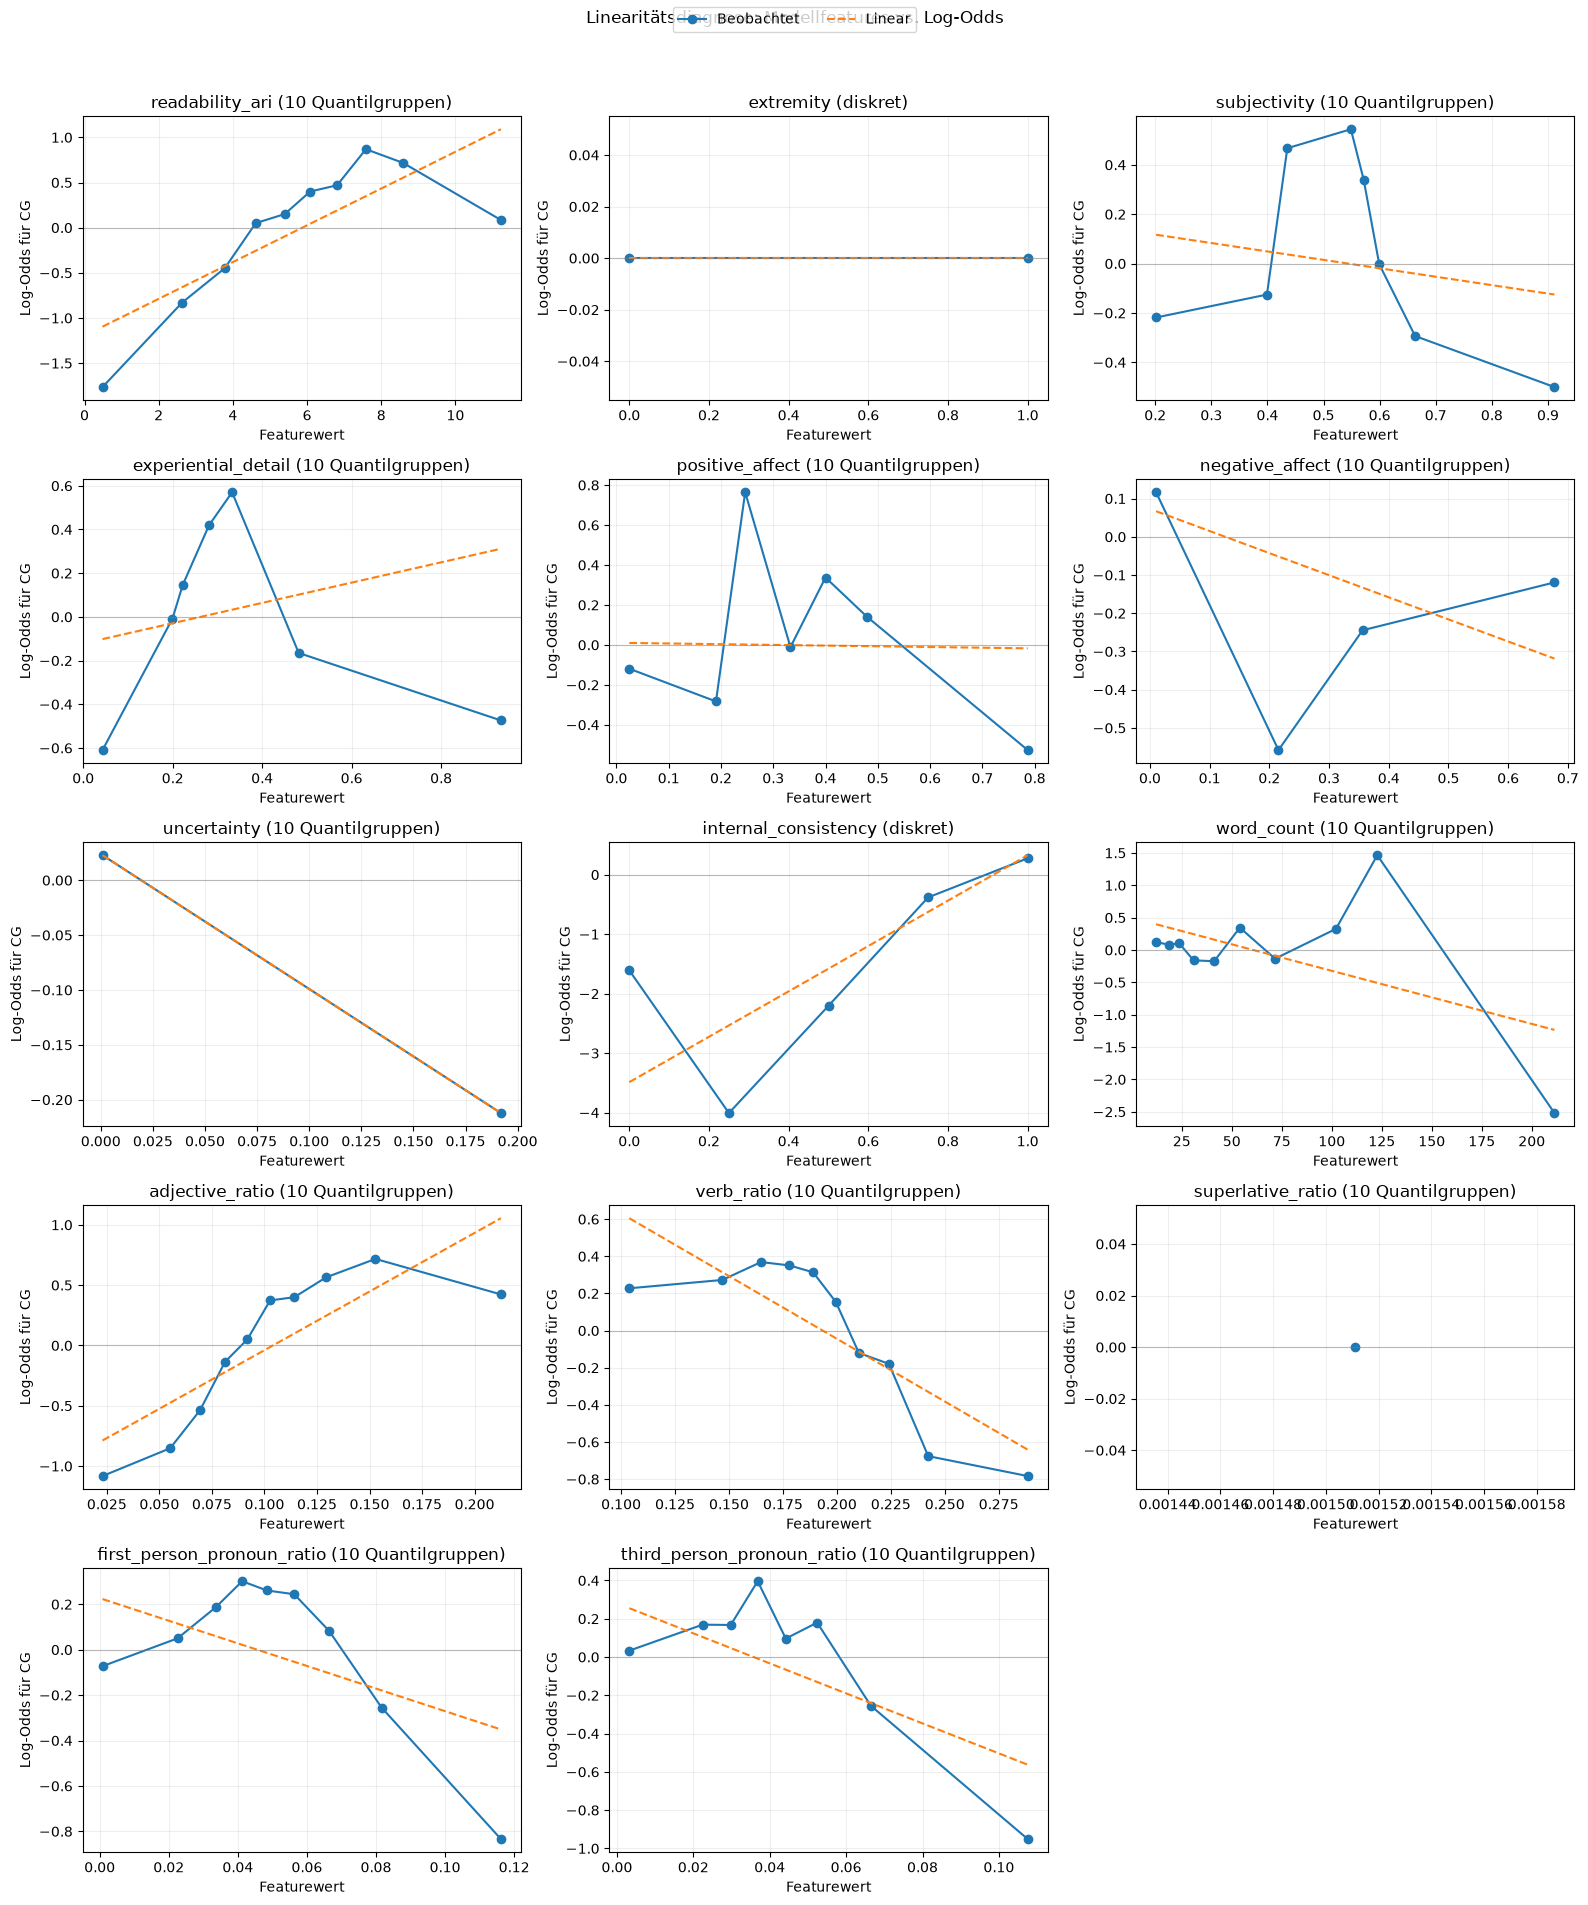

In [18]:
import math

import matplotlib.pyplot as plt
import numpy as np


def calculate_log_odds_summary(
    df: pd.DataFrame,
    feature: str,
    bins: int = 10,
) -> tuple[pd.DataFrame, bool]:
    feature_df = df[[feature, "label"]].dropna().copy()
    is_discrete = feature_df[feature].nunique() <= bins

    if is_discrete:
        feature_df["feature_group"] = feature_df[feature]
    else:
        feature_df["feature_group"] = pd.qcut(
            feature_df[feature],
            q=bins,
            duplicates="drop",
        )

    summary = (
        feature_df
        .groupby("feature_group", observed=True)
        .agg(
            feature_mean=(feature, "mean"),
            positive_count=("label", "sum"),
            sample_count=("label", "size"),
        )
        .reset_index(drop=True)
        .sort_values("feature_mean")
    )

    # Die 0.5-Korrektur verhindert unendliche Log-Odds bei Anteilen von 0 oder 1.
    probability = (
        summary["positive_count"] + 0.5
    ) / (
        summary["sample_count"] + 1
    )
    summary["log_odds"] = np.log(probability / (1 - probability))

    return summary, is_discrete


def plot_all_feature_linearities(
    df: pd.DataFrame,
    features: list[str],
    bins: int = 10,
):
    column_count = 3
    row_count = math.ceil(len(features) / column_count)
    figure, axes = plt.subplots(
        row_count,
        column_count,
        figsize=(16, 3.8 * row_count),
    )
    axes = np.atleast_1d(axes).ravel()

    for axis, feature in zip(axes, features):
        summary, is_discrete = calculate_log_odds_summary(
            df,
            feature,
            bins=bins,
        )
        x_values = summary["feature_mean"].to_numpy()
        y_values = summary["log_odds"].to_numpy()

        axis.plot(
            x_values,
            y_values,
            marker="o",
            label="Beobachtet",
        )

        if len(np.unique(x_values)) >= 2:
            coefficients = np.polyfit(
                x_values,
                y_values,
                deg=1,
                w=np.sqrt(summary["sample_count"]),
            )
            axis.plot(
                x_values,
                np.polyval(coefficients, x_values),
                linestyle="--",
                label="Linear",
            )

        feature_type = "diskret" if is_discrete else "10 Quantilgruppen"
        axis.set_title(f"{feature} ({feature_type})")
        axis.set_xlabel("Featurewert")
        axis.set_ylabel("Log-Odds für CG")
        axis.axhline(0, color="grey", linewidth=0.8, alpha=0.5)
        axis.grid(alpha=0.2)

    for axis in axes[len(features):]:
        axis.remove()

    handles, labels = axes[0].get_legend_handles_labels()
    figure.legend(handles, labels, loc="upper center", ncol=2)
    figure.suptitle("Linearitätsdiagnose: Modellfeatures vs. Log-Odds", y=1.0)
    figure.tight_layout(rect=(0, 0, 1, 0.98))
    plt.show()


plot_all_feature_linearities(final_llama, MODEL_FEATURE_COLUMNS)